In [1]:
# Cell 1
import scib
from scib.metrics import ilisi_graph, clisi_graph, kBET, graph_connectivity
from scib.metrics.silhouette import silhouette
from scib.metrics.metrics import ari
import scanpy as sc
import warnings
warnings.filterwarnings('ignore')
import numpy as np
np.random.seed(42)
sc.settings.verbosity = 3


In [2]:
%matplotlib inline

In [3]:
# Load data
adata_unharmonized = sc.read_h5ad('downloaded_adata_diseases_unharmonized.h5ad')


In [4]:
dataset_ids = ["84230ea4-998d-4aa8-8456-81dd54ce23af",'79ef1959-a6b4-4cac-82ca-30feaec48df1']


mask = adata_unharmonized.obs["dataset_id"].isin(dataset_ids)
adata_unharmonized_selected = adata_unharmonized[mask].copy()

# mask = adata_harmonized.obs["dataset_id"].isin(dataset_ids)
# adata_harmonized_selected=adata_harmonized[mask].copy()

In [5]:
adata_unharmonized_sample = adata_unharmonized_selected.copy()
# adata_harmonized_sample = adata_harmonized_selected.copy()


In [6]:
sc.pp.normalize_total(adata_unharmonized_selected, target_sum=1e4)
sc.pp.log1p(adata_unharmonized_selected)
sc.pp.pca(adata_unharmonized_selected,n_comps=50)
sc.pp.neighbors(adata_unharmonized_selected)
sc.tl.umap(adata_unharmonized_selected)



normalizing counts per cell


    finished (0:00:02)
computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


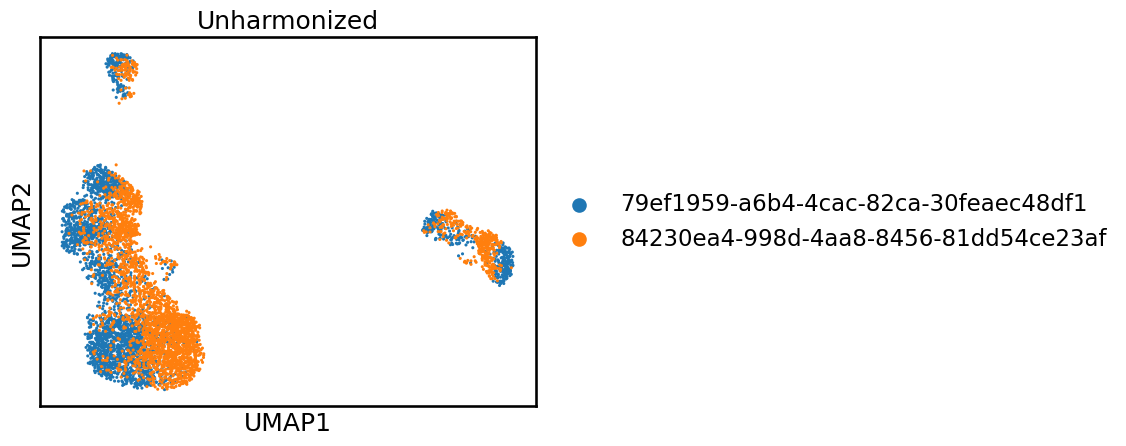

In [7]:

sc.pl.umap(adata_unharmonized_selected, color="dataset_id", title="Unharmonized",show=True)


Biolgical Conservation Metrics

In [ ]:
scib.pp.reduce_data(
    adata_unharmonized_selected, n_top_genes=2000, batch_key="dataset_id", pca=True, neighbors=True
)
scib.me.cluster_optimal_resolution(adata_unharmonized_selected, cluster_key="cluster", label_key="cell_type_original")


HVG
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Using 1297 HVGs from full intersect set
Using 703 HVGs from n_batch-1 set
Using 2000 HVGs
Computed 2000 highly variable genes
PCA
computing PCA
    with n_comps=50
    finished (0:00:00)
Nearest Neigbours
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
resolution: 0.2, nmi: 0.4928910007845873
resolution: 0.4, nmi: 0.3731234622583993
resolution: 0.6, nmi: 0.3278839118454228
resolution: 0.8, nmi: 0.29601336224737224
resolution: 1.0, nmi: 0.29620072643181933
resolution: 1.2, nmi: 0.28974845470127775
resolution: 1.4, nmi: 0.2764297753628868
resolution: 1.6, nmi: 0.26718092249749087
resolution: 1.8, nm

np.float64(0.2759850297871487)

In [ ]:
#ari
scib.me.ari(adata_unharmonized_selected, cluster_key="cluster", label_key="cell_type_original")

In [ ]:
#nmi
scib.me.nmi(adata_unharmonized_selected, cluster_key="cluster", label_key="cell_type_original")


0.4928910007845873

In [ ]:
#silhouette
scib.me.silhouette(adata_unharmonized_selected, label_key="cell_type_original", embed="X_pca")


0.6172724291682243

In [43]:
import scanpy as sc
import scib

# Precompute neighbors (pure Python)
sc.pp.pca(adata_unharmonized_selected, n_comps=50)
sc.pp.neighbors(adata_unharmonized_selected, n_neighbors=30, use_rep='X_pca')

# Use type_="knn" to force SCIB to reuse Scanpy neighbors
clisi_score = scib.me.clisi_graph(
    adata_unharmonized_selected,
    label_key="cell_type_original",
    type_="knn"  # <-- key change here
)

print("cLISI score:", clisi_score)


computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


/home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o)
/home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.34' not found (required by /home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o)
/home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o)
/home/krupavardhan4869@gmail.com/metenv/lib/python3.11/site-packages/scib/knn_graph/knn_graph.o: /lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (require

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/lisi_qnh4_dlm/graph_lisi_indices_0.txt'

kBET


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.stats import chisquare

def calculate_kbet_scores(adata, batch_key, obsm_keys, k=50, alpha=0.05, subsample=262104, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []
    
    # choose indices for subsampling
    if subsample is not None and subsample < adata.n_obs:
        idx = rng.choice(adata.n_obs, subsample, replace=False)
    else:
        idx = np.arange(adata.n_obs)
    
    batches = adata.obs[batch_key].values[idx]
    unique_batches, counts = np.unique(batches, return_counts=True)
    global_freq = counts / counts.sum()
    
    for key in obsm_keys:
        print(f"calculating kbet for {key}")
        if key not in adata.obsm:
            print(f"⚠️ Skipping {key} (not found in .obsm)")
            continue
        
        X = adata.obsm[key][idx, :]
        nn = NearestNeighbors(n_neighbors=k+1).fit(X)
        neigh_idx = nn.kneighbors(X, return_distance=False)[:, 1:]
        
        rejections = 0
        tested = 0
        for i in range(X.shape[0]):
            local_batches = batches[neigh_idx[i]]
            local_counts = np.array([np.sum(local_batches == b) for b in unique_batches])
            expected = global_freq * k
            
            # avoid invalid expected counts
            expected = np.where(expected < 1e-6, 1e-6, expected)
            
            chi2, pval = chisquare(local_counts, expected)
            tested += 1
            if pval < alpha:
                rejections += 1
        
        acceptance_rate = 1 - rejections / tested if tested > 0 else np.nan
        results.append({"embedding": key, "kBET": acceptance_rate, "n_cells": len(idx)})
    
    return pd.DataFrame(results)
